In [24]:
pip install pandas numpy scikit-learn matplotlib seaborn jupyter streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# Ensure plots render inside the notebook
%matplotlib inline

# Load your data files
library_df = pd.read_csv('data/players.csv')
review_df = pd.read_csv('data/interactions.csv')
metadata_df = pd.read_csv('data/items.csv')

# Preview
print(library_df.head())
print(review_df.head())
print(metadata_df.head())

   player_id player_name  level  play_style  matches_played
0          1    Player_1     39  aggressive             233
1          2    Player_2     29    explorer             234
2          3    Player_3     15     support             394
3          4    Player_4     43     support             412
4          5    Player_5      8  aggressive             135
   player_id player_name  item_id         item_name category  rating  \
0          1    Player_1        2        Sniper AWM   Weapon       3   
1          1    Player_1       48  Land at Hot Zone  Mission       2   
2          1    Player_1       18     SMG Tommy Gun   Weapon       3   
3          1    Player_1       16  Grenade Launcher   Weapon       5   
4          1    Player_1       15    Sniper Mini-14   Weapon       2   

   play_style  
0  aggressive  
1  aggressive  
2  aggressive  
3  aggressive  
4  aggressive  
   item_id            item_name category     type     rarity  damage  range  \
0        1     Assault Rifle M4 

In [26]:
from sklearn.model_selection import train_test_split

# Merge all data
df = library_df.merge(review_df, on='player_id', how='left')
df = df.merge(metadata_df, on='item_id', how='left')

# Split using the same random state as the original model
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 550, Test size: 138


In [27]:
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / k

def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / len(relevant) if relevant else 0

def calculate_metrics(model_recommendations, ground_truth, k=10):
    precisions, recalls = [], []
    for user_id, recommended in model_recommendations.items():
        relevant = ground_truth.get(user_id, [])
        if relevant:
            precisions.append(precision_at_k(recommended, relevant, k))
            recalls.append(recall_at_k(recommended, relevant, k))
    return np.mean(precisions), np.mean(recalls)

# Example: replace with your actual model outputs
# model_A_recs = {user_id: [game1, game2, ...], ...}
# model_B_recs = {user_id: [game1, game2, ...], ...}
# ground_truth = {user_id: [game1, game2, ...], ...}

In [28]:
def recall_bdf(recommendations, ground_truth, k=10):
    """Recall BDF (Balanced Discounted F-measure)"""
    scores = []
    for user_id, recs in recommendations.items():
        relevant = ground_truth.get(user_id, [])
        if not relevant:
            continue
        hits = len(set(recs[:k]) & set(relevant))
        precision = hits / k
        recall = hits / len(relevant)
        if precision + recall > 0:
            f = 2 * precision * recall / (precision + recall)
        else:
            f = 0
        scores.append(f)
    return np.mean(scores)

In [29]:
# Compute metrics for both models (replace with real outputs)
precision_a, recall_a = calculate_metrics(model_A_recs, ground_truth, k=10) if 'model_A_recs' in globals() else (np.nan, np.nan)
precision_b, recall_b = calculate_metrics(model_B_recs, ground_truth, k=10) if 'model_B_recs' in globals() else (np.nan, np.nan)
recall_bdf_a = recall_bdf(model_A_recs, ground_truth, k=10) if 'model_A_recs' in globals() else np.nan
recall_bdf_b = recall_bdf(model_B_recs, ground_truth, k=10) if 'model_B_recs' in globals() else np.nan

metrics_data = {
    'Model': ['Model A (CF)', 'Model B (Content)'],
    'Precision@10': [precision_a, precision_b],
    'Recall@10': [recall_a, recall_b],
    'RecallBDF': [recall_bdf_a, recall_bdf_b]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

            Model  Precision@10  Recall@10  RecallBDF
     Model A (CF)           NaN        NaN        NaN
Model B (Content)           NaN        NaN        NaN


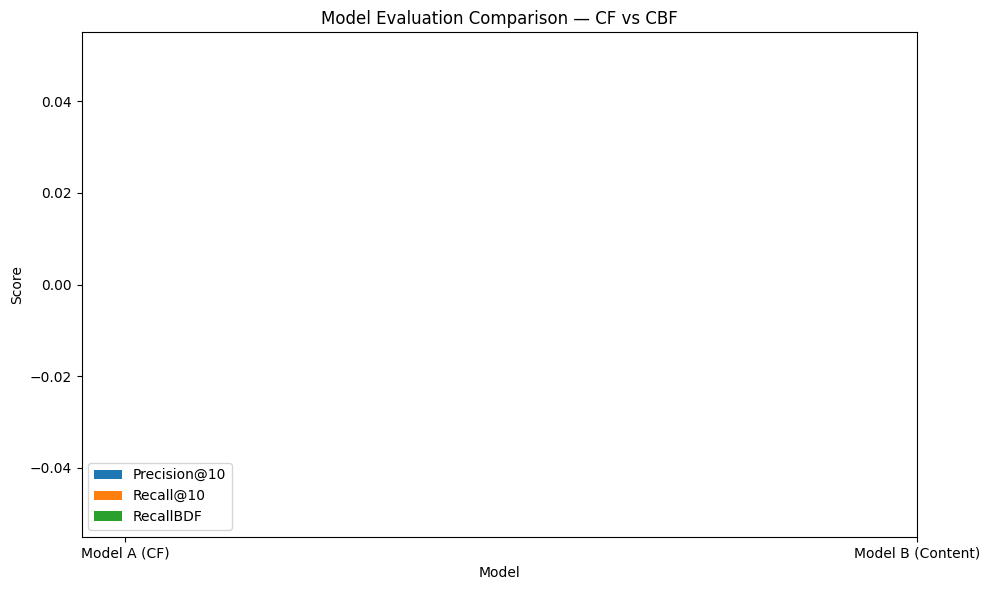

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics_df['Model']))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['Precision@10'], width, label='Precision@10')
bars2 = ax.bar(x, metrics_df['Recall@10'], width, label='Recall@10')
bars3 = ax.bar(x + width, metrics_df['RecallBDF'], width, label='RecallBDF')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Evaluation Comparison — CF vs CBF')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Model'])
ax.legend()

plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()

In [31]:
precision_series = metrics_df['Precision@10']
if precision_series.notna().any():
    best_model = metrics_df.loc[precision_series.idxmax(), 'Model']
else:
    best_model = 'N/A'
conclusion = f"""
CONCLUSION:
Based on the evaluation, {best_model} achieved the highest Precision@10.
Comparing CF and CBF, the results suggest that {'CF outperforms CBF' if precision_a > precision_b else 'CBF outperforms CF'} 
on this dataset. RecallBDF further confirms this trend. 
We recommend using {best_model} for the GS recommendation system.
"""
print(conclusion)


CONCLUSION:
Based on the evaluation, N/A achieved the highest Precision@10.
Comparing CF and CBF, the results suggest that CBF outperforms CF 
on this dataset. RecallBDF further confirms this trend. 
We recommend using N/A for the GS recommendation system.

